In [1]:
#загрузка необходимых библиотек
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
#загрузка датасета
data = pd.read_csv('Credit.csv')
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


DataSet Information:

Loan_ID :Provides the id number given to the candidature .
Gender :The gender of a candidature.
Married :The candidature marital Status.
Dependants : The number of people dependent on the candidate.
Education :The education of a candidate.
Self_employed :The employment type of a candidate.
ApplicantIncome :Total income of a candidate.
CoapplicantIncome:Total income of a coapplicant of a candidate.
LoanAmount :Total amount of a loan.
Loan_Amount_Term :The total time duration of a loan.
Credit_History :The credit score of a candidate.
Property_Area : From which region the candidate belongs.
Loan_Status :Whether the loan is approved or not.

# 1. EDA

In [4]:
#информация о датасете
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### 1.1 Пропуски в данных

In [5]:
#обработка пропущеных значений
(data.isna().sum() / len(data)).round(4) * 100

Loan_ID              0.00
Gender               2.12
Married              0.49
Dependents           2.44
Education            0.00
Self_Employed        5.21
ApplicantIncome      0.00
CoapplicantIncome    0.00
LoanAmount           3.58
Loan_Amount_Term     2.28
Credit_History       8.14
Property_Area        0.00
Loan_Status          0.00
dtype: float64

In [6]:
data[['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']].isnull().corr()

,Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History
Gender,1.000000,-0.010306,-0.023274,-0.034486,-0.028352,-0.022466,-0.002425
Married,-0.010306,1.000000,0.442800,-0.016431,0.112157,-0.010704,-0.020863
Dependents,-0.023274,0.442800,1.000000,-0.037106,0.083013,0.046503,-0.047117
Self_Employed,-0.034486,-0.016431,-0.037106,1.000000,-0.005779,0.013272,0.090936
LoanAmount,-0.028352,0.112157,0.083013,-0.005779,1.000000,-0.029447,-0.025359
Loan_Amount_Term,-0.022466,-0.010704,0.046503,0.013272,-0.029447,1.000000,-0.045481
Credit_History,-0.002425,-0.020863,-0.047117,0.090936,-0.025359,-0.045481,1.000000


##### т.к. пропуски в данных носят случайный характер (видно по матрице корреляций), строки с пропусками можно просто удалить

In [7]:
#удаление пропущенных данных
data.dropna(axis = 'index', subset = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'], inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            480 non-null    object 
 1   Gender             480 non-null    object 
 2   Married            480 non-null    object 
 3   Dependents         480 non-null    object 
 4   Education          480 non-null    object 
 5   Self_Employed      480 non-null    object 
 6   ApplicantIncome    480 non-null    int64  
 7   CoapplicantIncome  480 non-null    float64
 8   LoanAmount         480 non-null    float64
 9   Loan_Amount_Term   480 non-null    float64
 10  Credit_History     480 non-null    float64
 11  Property_Area      480 non-null    object 
 12  Loan_Status        480 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 52.5+ KB


### 1.2 Гипотезы:
#### 1) Вероятность отдать кредит выше тогда, когда больше ApplicantIncome и CoapplicantIncome
#### 2) Вероятность отдать кредит выше тогда, когда образование выше
#### 3) На целевую переменную могут сильно влиять LoanAmount и Loan_Amount_Term
#### 4) На целевую переменную чуть меньше могут влиять Married, Gender, Property_Area
#### 5) Основной параметр, от. которого зависит будет выдан кредит или нет это - Self_Employed

### 1.3 Визуализация

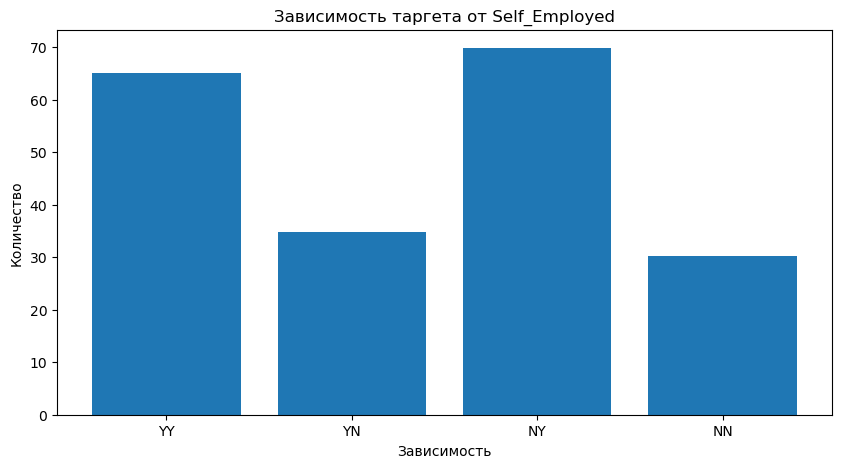

In [8]:
#гистограма зависимости таргета от 
names = ['YY', 'YN', 'NY', 'NN']
values = [len(data.loc[((data['Self_Employed'] == 'Yes') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Self_Employed'] == 'Yes') & (data['Loan_Status'] == 'N'))]),
          len(data.loc[((data['Self_Employed'] == 'No') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Self_Employed'] == 'No') & (data['Loan_Status'] == 'N'))])]
sum_val1 = sum(values[:2])
sum_val2 = sum(values[2:4])
x = [(values[0] / sum_val1) * 100, (values[1] / sum_val1) * 100,
     (values[2] / sum_val2) * 100, (values[3] / sum_val2) * 100]
fig = plt.figure(figsize = (10, 5))
plt.bar(names, x)
plt.title('Зависимость таргета от Self_Employed')
plt.xlabel('Зависимость')
plt.ylabel('Количество')
plt.show()

Можно видеть, что подтверждается гипотеза (5)

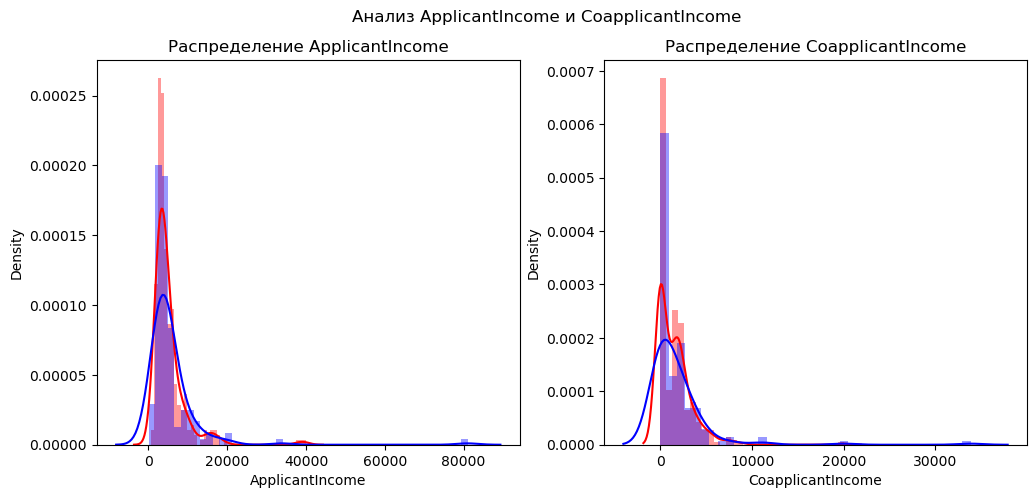

In [9]:
#анализ ApplicantIncome и CoapplicantIncome
fig, axes = plt.subplots(1, 2, figsize=(12,5)) 
axes[0].set_title('Распределение ApplicantIncome')
axes[1].set_title('Распределение CoapplicantIncome')
sns.distplot(data['ApplicantIncome'].loc[data['Loan_Status'] == 'Y'], ax=axes[0], color='r')
sns.distplot(data['ApplicantIncome'].loc[data['Loan_Status'] == 'N'], ax=axes[0], color='b')
sns.distplot(data['CoapplicantIncome'].loc[data['Loan_Status'] == 'Y'], ax=axes[1], color='r')
sns.distplot(data['CoapplicantIncome'].loc[data['Loan_Status'] == 'N'], ax=axes[1], color='b')
fig.suptitle('Анализ ApplicantIncome и CoapplicantIncome')
plt.show();

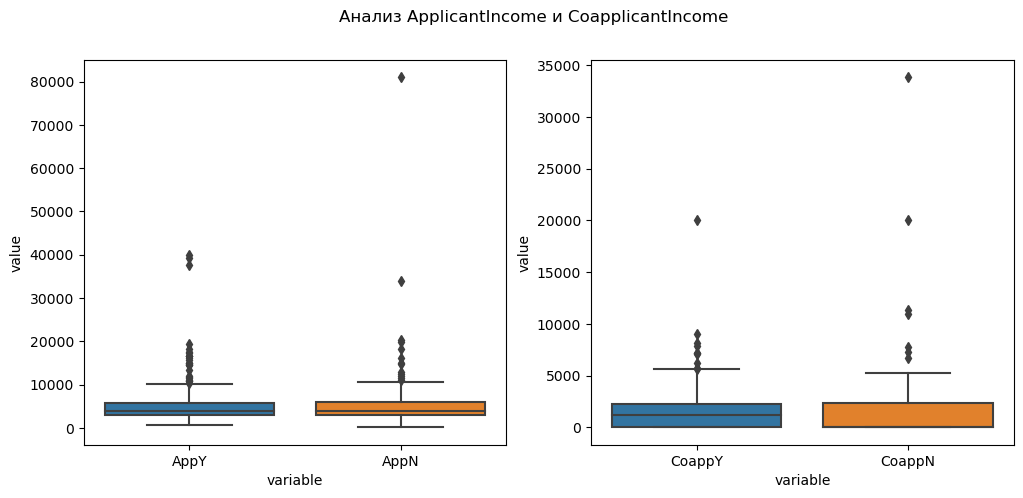

In [10]:
#boxplot'ы для переменных ApplicantIncome и CoapplicantIncome
fig, axes = plt.subplots(1, 2, figsize=(12,5))
values = pd.DataFrame({'AppY': data['ApplicantIncome'].loc[data['Loan_Status'] == 'Y'], 
                       'AppN': data['ApplicantIncome'].loc[data['Loan_Status'] == 'N']})
values_melted = pd.melt(values)
covalues = pd.DataFrame({'CoappY': data['CoapplicantIncome'].loc[data['Loan_Status'] == 'Y'], 
                         'CoappN': data['CoapplicantIncome'].loc[data['Loan_Status'] == 'N']})
covalues_melted = pd.melt(covalues)
sns.boxplot(x = 'variable', y = 'value', data=values_melted, ax=axes[0])
sns.boxplot(x = 'variable', y = 'value', data=covalues_melted, ax=axes[1])
fig.suptitle('Анализ ApplicantIncome и CoapplicantIncome')
plt.show();

In [11]:
#выведем среднее по ApplicantIncome для хороших и плохих заемщиков
arr = [data['ApplicantIncome'].loc[data['Loan_Status'] == 'Y'].mean(),
       data['ApplicantIncome'].loc[data['Loan_Status'] == 'N'].mean()]
print(arr)

[5201.093373493976, 5730.189189189189]


In [12]:
#выведем моду по ApplicantIncome для хороших и плохих заемщиков
arr = [data['ApplicantIncome'].loc[data['Loan_Status'] == 'Y'].mode(),
       data['ApplicantIncome'].loc[data['Loan_Status'] == 'N'].mode()]
print(arr)

[0    2500
Name: ApplicantIncome, dtype: int64, 0    4583
Name: ApplicantIncome, dtype: int64]


Судя по графикам, можно сказать, что ApplicantIncome и CoapplicantIncome не сильно влияют на выдачу кредита

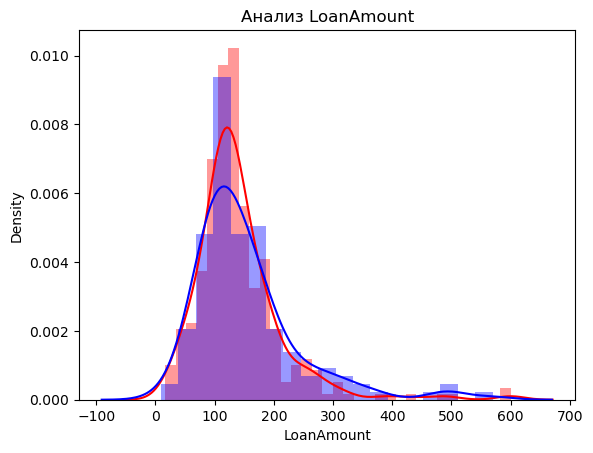

In [13]:
#анализ LoanAmount 
sns.distplot(data['LoanAmount'].loc[data['Loan_Status'] == 'Y'], color='r')
sns.distplot(data['LoanAmount'].loc[data['Loan_Status'] == 'N'], color='b')
plt.title('Анализ LoanAmount')

plt.show();

In [14]:
arr = [data['LoanAmount'].loc[data['Loan_Status'] == 'Y'].mean(), data['LoanAmount'].loc[data['Loan_Status'] == 'N'].mean()]
print(arr)

[140.88253012048193, 153.3783783783784]


In [15]:
arr = [data['LoanAmount'].loc[data['Loan_Status'] == 'Y'].median(), data['LoanAmount'].loc[data['Loan_Status'] == 'N'].median()]
print(arr)

[128.0, 128.0]


In [16]:
arr = [data['LoanAmount'].loc[data['Loan_Status'] == 'Y'].mode(), data['LoanAmount'].loc[data['Loan_Status'] == 'N'].mode()]
print(arr)

[0    120.0
Name: LoanAmount, dtype: float64, 0    110.0
1    113.0
2    160.0
Name: LoanAmount, dtype: float64]


Аналогичная ситуация получается с LoanAmount

In [17]:
#уникальные значения Education
data['Education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

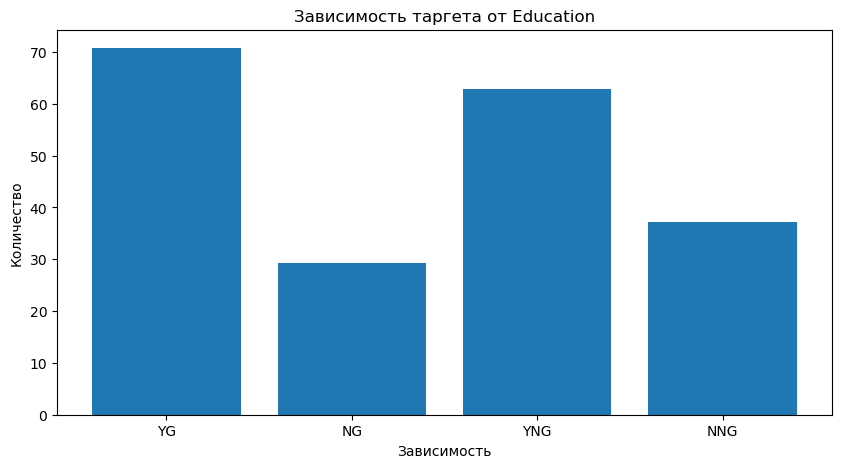

In [18]:
#анализ Education
names = ['YG', 'NG', 'YNG', 'NNG']
values = [len(data.loc[((data['Education'] == 'Graduate') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Education'] == 'Graduate') & (data['Loan_Status'] == 'N'))]),
          len(data.loc[((data['Education'] == 'Not Graduate') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Education'] == 'Not Graduate') & (data['Loan_Status'] == 'N'))])]
sum_val1= sum(values[:2])
sum_val2= sum(values[2:4])
x = [(values[0] / sum_val1) * 100, (values[1] / sum_val1) * 100,
     (values[2] / sum_val2) * 100, (values[3] / sum_val2) * 100]
fig = plt.figure(figsize = (10, 5))
plt.bar(names, x)
plt.title('Зависимость таргета от Education')
plt.xlabel('Зависимость')
plt.ylabel('Количество')
plt.show();

Нетрудно видеть, что подтверждается гипотеза (2)

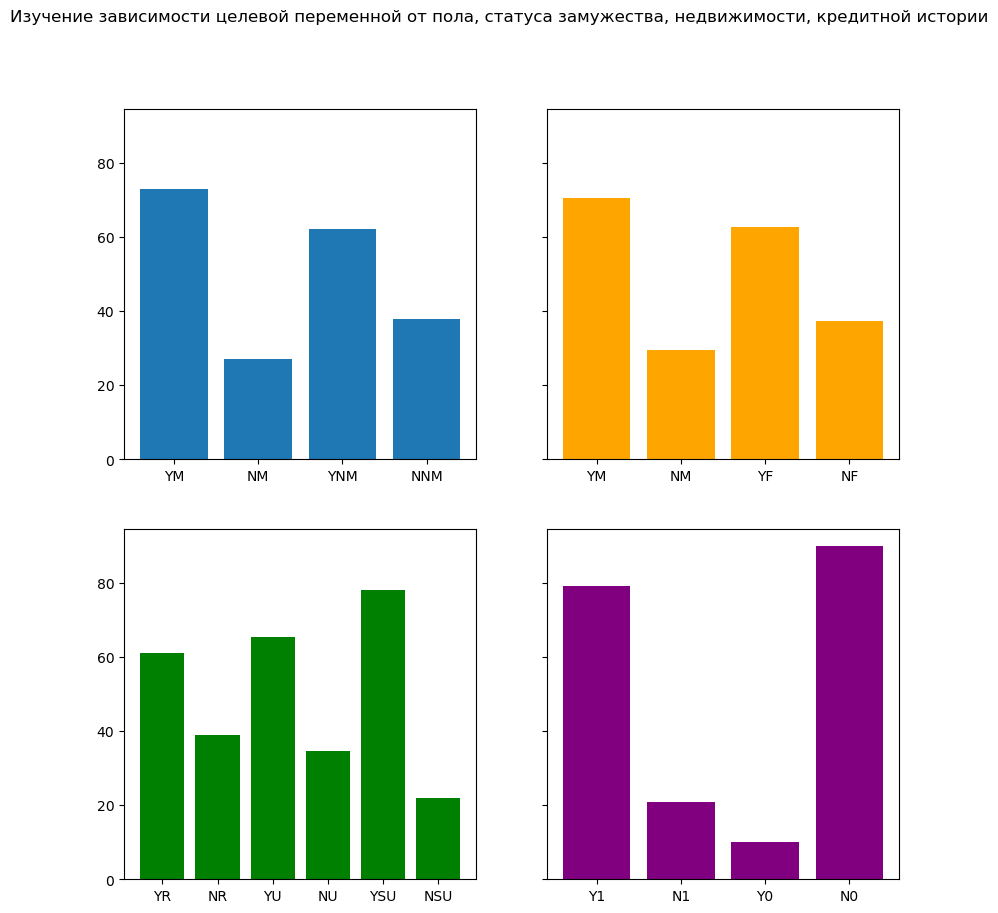

In [19]:
#анализ четвертой гипотезы
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharey=True)

names = ['YM', 'NM', 'YNM', 'NNM']
values = [len(data.loc[((data['Married'] == 'Yes') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Married'] == 'Yes') & (data['Loan_Status'] == 'N'))]),
          len(data.loc[((data['Married'] == 'No') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Married'] == 'No') & (data['Loan_Status'] == 'N'))])]

sum_val1 = sum(values[:2])
sum_val2 = sum(values[2:4])

x = [(values[0] / sum_val1) * 100, (values[1] / sum_val1) * 100,
     (values[2] / sum_val2) * 100, (values[3] / sum_val2) * 100]


names_1 = ['YM', 'NM', 'YF', 'NF']
values = [len(data.loc[((data['Gender'] == 'Male') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Gender'] == 'Male') & (data['Loan_Status'] == 'N'))]),
          len(data.loc[((data['Gender'] == 'Female') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Gender'] == 'Female') & (data['Loan_Status'] == 'N'))])]

sum_val1 = sum(values[:2])
sum_val2 = sum(values[2:4])

y = [(values[0] / sum_val1) * 100, (values[1] / sum_val1) * 100,
     (values[2] / sum_val2) * 100, (values[3] / sum_val2) * 100]


names_2 = ['YR', 'NR', 'YU', 'NU', 'YSU', 'NSU']
values = [len(data.loc[((data['Property_Area'] == 'Rural') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Property_Area'] == 'Rural') & (data['Loan_Status'] == 'N'))]),
          len(data.loc[((data['Property_Area'] == 'Urban') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Property_Area'] == 'Urban') & (data['Loan_Status'] == 'N'))]),
          len(data.loc[((data['Property_Area'] == 'Semiurban') & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Property_Area'] == 'Semiurban') & (data['Loan_Status'] == 'N'))])]

sum_val1 = sum(values[:2])
sum_val2 = sum(values[2:4])
sum_val3 = sum(values[4:6])

z = [(values[0] / sum_val1) * 100, (values[1] / sum_val1) * 100,
     (values[2] / sum_val2) * 100, (values[3] / sum_val2) * 100,
     (values[4] / sum_val3) * 100, (values[5] / sum_val3) * 100]


names_3 = ['Y1', 'N1', 'Y0', 'N0']
values = [len(data.loc[((data['Credit_History'] == 1.0) & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Credit_History'] == 1.0) & (data['Loan_Status'] == 'N'))]),
          len(data.loc[((data['Credit_History'] == 0.0) & (data['Loan_Status'] == 'Y'))]),
          len(data.loc[((data['Credit_History'] == 0.0) & (data['Loan_Status'] == 'N'))])]

sum_val1 = sum(values[:2])
sum_val2 = sum(values[2:4])

k = [(values[0] / sum_val1) * 100, (values[1] / sum_val1) * 100,
     (values[2] / sum_val2) * 100, (values[3] / sum_val2) * 100]

axes[0][0].bar(names, x)
axes[0][1].bar(names_1, y, color='orange')
axes[1][0].bar(names_2, z, color='green')
axes[1][1].bar(names_3, k, color='purple')

plt.suptitle("Изучение зависимости целевой переменной от пола, статуса замужества, недвижимости, кредитной истории")
plt.show();

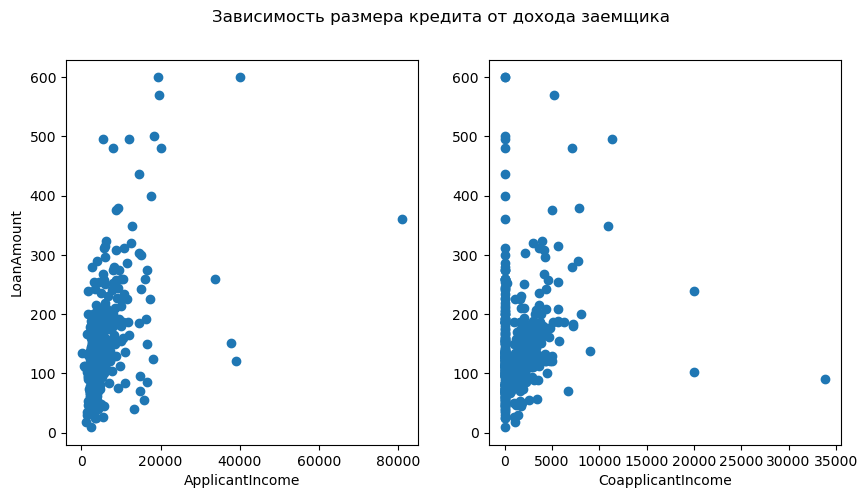

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes[0].scatter(y=data['LoanAmount'], x=data['ApplicantIncome'])
axes[1].scatter(y=data['LoanAmount'], x=data['CoapplicantIncome'])
plt.suptitle("Зависимость размера кредита от дохода заемщика")
axes[0].set_xlabel('ApplicantIncome')
axes[1].set_xlabel('CoapplicantIncome')
axes[0].set_ylabel('LoanAmount')
plt.show();

Text(0.5, 1.0, 'Зависимость выдачи от зависимых людей')

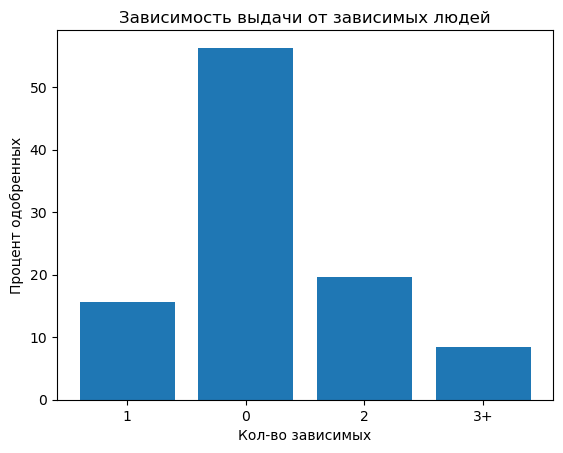

In [21]:
x = data['Dependents'].unique()
y = []

for i in range(len(x)):
    y.append(len(data.loc[(data['Dependents'] == x[i]) & (data['Loan_Status'] == 'Y')]))
    
s = sum(y)
    
for i in range(len(y)):
     y[i] = (y[i] / s) * 100

plt.bar(x, y)
plt.xlabel('Кол-во зависимых')
plt.ylabel('Процент одобренных')
plt.title('Зависимость выдачи от зависимых людей')

### 1.4 Изучение таргет переменной

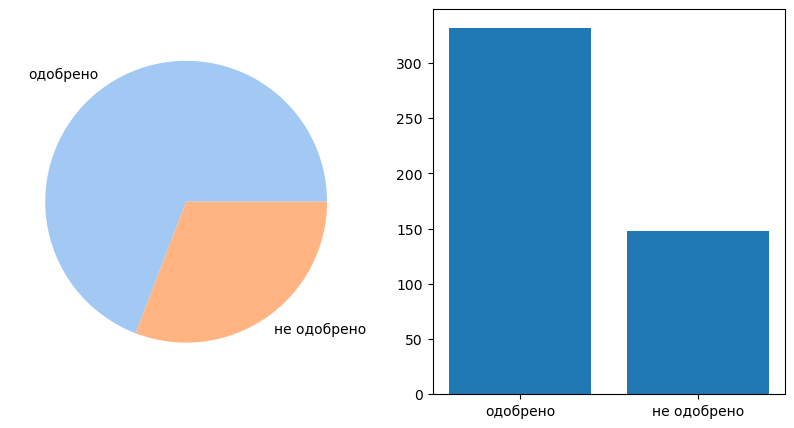

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
values = [len(data.loc[data['Loan_Status'] == 'Y']), len(data.loc[data['Loan_Status'] == 'N'])]
labels = ['одобрено', 'не одобрено']
colors = sns.color_palette('pastel')[:2]
axes[0].pie(values, labels=labels, colors=colors)
axes[1].bar(labels, values)
plt.show();

# 2. Обработка данных

In [23]:
#удалим столбец с id, так как он бесполезен для модели
data = data.drop('Loan_ID',  axis=1)
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [24]:
#заменим в категориальных переменных пол, статус замужества, образование, самозанятость строки на 1 и 0
data['Gender'] = data['Gender'].replace(['Male', 'Female'], [1, 0])
data['Married'] = data['Married'].replace(['Yes', 'No'], [1, 0]) 
data['Education'] = data['Education'].replace(['Graduate', 'Not Graduate'], [1, 0])
data['Self_Employed'] = data['Self_Employed'].replace(['Yes', 'No'], [1, 0])
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [25]:
#заменим в переменной Dependents 0 за 0, 1 за 1, 2 за 2, 3+ как 3
data['Dependents'] = data['Dependents'].replace(['0', '1', '2', '3+'], [0, 1, 2, 3])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             480 non-null    int64  
 1   Married            480 non-null    int64  
 2   Dependents         480 non-null    int64  
 3   Education          480 non-null    int64  
 4   Self_Employed      480 non-null    int64  
 5   ApplicantIncome    480 non-null    int64  
 6   CoapplicantIncome  480 non-null    float64
 7   LoanAmount         480 non-null    float64
 8   Loan_Amount_Term   480 non-null    float64
 9   Credit_History     480 non-null    float64
 10  Property_Area      480 non-null    object 
 11  Loan_Status        480 non-null    object 
dtypes: float64(4), int64(6), object(2)
memory usage: 48.8+ KB


In [26]:
#заменим таргет переменную аналогично уже проделанным заменам
data['Loan_Status'] = data['Loan_Status'].replace(['Y', 'N'], [1, 0])
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,Urban,1


In [29]:
#аналогично закодируем Property_Area
data['Property_Area'] = data['Property_Area'].replace(['Rural', 'Urban', 'Semiurban'], [0, 1, 2])
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,1,1


In [31]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,1
5,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,1,1


In [33]:
X = data[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']]
y = data['Loan_Status']

In [34]:
# импортируем необходимый модуль
from sklearn.model_selection import train_test_split
 
# размер тестовой выборки составит 30%
# также зададим точку отсчета для воспроизводимости результата
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.3, 
                                                    random_state = 42)

In [35]:
# импортируем логистическую регрессию из модуля linear_model библиотеки sklearn
from sklearn.linear_model import LogisticRegression
 
# создадим объект этого класса и запишем его в переменную model
model = LogisticRegression()
 
# обучим нашу модель
model.fit(X_train, y_train)
 
# выполним предсказание класса на тестовой выборке
y_pred = model.predict(X_test)

In [36]:
# построим матрицу ошибок
from sklearn.metrics import confusion_matrix
 
# передадим ей тестовые и прогнозные значения
# поменяем порядок так, чтобы злокачественные опухоли были положительным классом
model_matrix = confusion_matrix(y_test, y_pred, labels = [1,0])
 
# для удобства создадим датафрейм
model_matrix_df = pd.DataFrame(model_matrix)
model_matrix_df

,0,1
0,99,1
1,29,15


In [38]:
# добавим подписи к столбцам и строкам через параметры columns и index
model_matrix_df = pd.DataFrame(model_matrix, columns = ['Прогноз выдача', 'Прогноз не выдача'], index = ['Факт выдача', 'Факт не выдача'])
model_matrix_df

,Прогноз выдача,Прогноз не выдача
Факт выдача,99,1
Факт не выдача,29,15


In [40]:
# рассчитаем accuracy или долю правильных прогнозов

from sklearn.metrics import accuracy_score
 
model_accuracy = accuracy_score(y_test, y_pred)
round(model_accuracy, 2)

0.79

In [45]:
# рассчитаем f1 score
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')
round(f1, 2)

0.76